# PC vs lncRNA — Descriptive Element Statistics

Comparative analysis of protein-coding (PC) and lncRNA transcripts across:
- **Transcript length**
- **TE elements** (transposable elements: DNA, LINE, LTR, SINE, etc.) — counts by class/family and coverage statistics
- **LCTR elements** (low complexity / tandem repeats) — counts and coverage
- **NBD elements** (Non-B DNA motifs: APR, DR, GQ, IR, MR, STR, TRI, Z) — counts and coverage

**Data sources**
- TE + LCTR: `paper/te_pipeline/results/gencode.v47/features/all_transcripts_te_features.csv`
- RepeatMasker raw: `paper/te_pipeline/results/gencode.v47/repeatmasker/all_transcripts.out`
- NBD: `paper/nonb-pipeline/results/gencode.v47/extended_analysis/features_nonb_features.csv`

## 1. Imports and Setup

In [ ]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────────────────
DATASET = "gencode.v47.common.cdhit.cv"
BASE = Path("/mnt/cbib/LNClassifier/paper")
REP_FEATURES  = BASE / "te_pipeline/results/te_analysis_flexible/features/all_transcripts_te_features.corrected.csv"
RM_OUT        = BASE / "te_pipeline/results/te_analysis_flexible/repeatmasker/all_transcripts.out"
NBD_FEATURES  = BASE / "nonb-pipeline/results/gencode.v47.transcripts/extended_analysis/features_nonb_features.csv"
LEGACY_NBD_FEATURES  = BASE / "nonb-pipeline/results/gencode.v47.legacy/extended_analysis/features_nonb_features.corrected.csv"

# ── Output directory for supplementary tables ────────────────────────────────
TABLE_OUT = BASE / 'results' / DATASET / 'supplementary_tables' / 'element_statistics_tables'
TABLE_OUT.mkdir(parents=True, exist_ok=True)

# ── Color palette  ───────────────────────────────────────────────────────────
CLASS_PALETTE = {"coding": "#d95f02", "lncRNA": "#1b9e77"}
CLASS_ORDER   = ["coding", "lncRNA"]
CLASS_LABELS  = {"coding": "Protein-coding", "lncRNA": "lncRNA"}

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams["figure.dpi"] = 300

print("✓ Setup complete")
print(f"  REP features : {REP_FEATURES}")
print(f"  RM output    : {RM_OUT}")
print(f"  NBD features : {NBD_FEATURES}")
print(f"  Legacy NBD features : {LEGACY_NBD_FEATURES}")
print(f"  Table output : {TABLE_OUT}")


✓ Setup complete
  REP features : /mnt/cbib/LNClassifier/paper/te_pipeline/results/te_analysis_flexible/features/all_transcripts_te_features.corrected.csv
  RM output    : /mnt/cbib/LNClassifier/paper/te_pipeline/results/te_analysis_flexible/repeatmasker/all_transcripts.out
  NBD features : /mnt/cbib/LNClassifier/paper/nonb-pipeline/results/gencode.v47.transcripts/extended_analysis/features_nonb_features.csv
  Legacy NBD features : /mnt/cbib/LNClassifier/paper/nonb-pipeline/results/gencode.v47.legacy/extended_analysis/features_nonb_features.corrected.csv
  Table output : /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/supplementary_tables/element_statistics_tables


## 2. Load Datasets

### 2.1 Load transcripts in dataset

In [ ]:
import sys
sys.path.append("/mnt/cbib/LNClassifier/paper/workflow/")
from utils.entropy import load_dataset

dataset = load_dataset(DATASET)
dset_ids = dataset["features"].index
print(f"✓ Loaded dataset '{DATASET}' with {len(dset_ids)} transcripts")

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC
✓ Loaded dataset 'gencode.v47.common.cdhit.cv' with 111652 transcripts


### 2.2 Load REP Pipeline Results

In [ ]:
rep = pd.read_csv(REP_FEATURES, index_col="transcript_id", low_memory=False)
rep = rep.loc[dset_ids].copy()  # Subset to transcripts in dataset

# Normalise coding_class to match palette keys
rep["coding_class"] = rep["coding_class"].str.strip()

pc  = rep[rep["coding_class"] == "coding"]
lnc = rep[rep["coding_class"] == "lncRNA"]

print(f"REP feature table: {rep.shape[0]:,} transcripts × {rep.shape[1]} features")
print(f"  Protein-coding : {len(pc):,}")
print(f"  lncRNA         : {len(lnc):,}")
rep[["transcript_length", "coding_class", "te_count", "lctr_count"]].head(3)


REP feature table: 111,652 transcripts × 173 features
  Protein-coding : 66,376
  lncRNA         : 45,276


,transcript_length,coding_class,te_count,lctr_count
seq_ID,,,,
ENST00000000412.8,2450,coding,0,1
ENST00000002596.6,7160,coding,5,1
ENST00000002829.8,3607,coding,0,2


In [ ]:
rep[[c for c in rep.columns if "pct" in c]].head(3)

,te_sum_hit_length_pct,te_min_hit_length_pct,te_mean_hit_length_pct,te_max_hit_length_pct,te_gaps_mean_pct,te_gaps_median_pct,te_gaps_max_pct,te_gaps_min_pct,lctr_total_length_pct,lctr_mean_length_pct,unknown_total_length_pct,unknown_mean_length_pct,global_rm_total_length_pct,global_gaps_mean_pct,global_gaps_median_pct
seq_ID,,,,,,,,,,,,,,,
ENST00000000412.8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.510204,1.510204,0.0,0.0,1.510204,49.244898,49.244898
ENST00000002596.6,16.689944,1.480447,3.337989,6.801676,13.885009,7.060056,36.131285,2.402235,0.586592,0.586592,0.0,0.0,17.276536,11.817638,7.667598
ENST00000002829.8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.051566,1.025783,0.0,0.0,2.051566,32.649478,24.286110


### 2.3 Load NBD Pipeline Results

In [ ]:
nbd = pd.read_csv(NBD_FEATURES, index_col="transcript_id", low_memory=False)
nbd = nbd.loc[dset_ids].copy()  # Subset to transcripts in dataset

nbd["coding_class"] = nbd["coding_class"].str.strip()


nbd_pc  = nbd[nbd["coding_class"] == "coding"]
nbd_lnc = nbd[nbd["coding_class"] == "lncRNA"]

# NBD motif types present in the file
NBD_MOTIFS = ["apr", "dr", "gq", "ir", "mr", "str", "tri", "z"]
NBD_LABELS = {
    "apr": "APR", "dr": "DR", "gq": "G4",
    "ir": "IR", "mr": "MR", "str": "STR", "tri": "TRI", "z": "Z-DNA",
}

print(f"NBD feature table: {nbd.shape[0]:,} transcripts × {nbd.shape[1]} features")
print(f"  Protein-coding : {len(nbd_pc):,}")
print(f"  lncRNA         : {len(nbd_lnc):,}")
nbd[["transcript_length", "coding_class", "total_nonb_count", "total_nonb_coverage_pct"]].head(3)

NBD feature table: 111,652 transcripts × 189 features
  Protein-coding : 66,376
  lncRNA         : 45,276


,transcript_length,coding_class,total_nonb_count,total_nonb_coverage_pct
seq_ID,,,,
ENST00000000412.8,9285,coding,25.0,5.320409
ENST00000002596.6,35745,coding,134.0,9.069800
ENST00000002829.8,33752,coding,226.0,17.542664


In [ ]:
nbd_leg = pd.read_csv(LEGACY_NBD_FEATURES, index_col="transcript_id", low_memory=False)
nbd_leg = nbd_leg.loc[dset_ids].copy()  # Subset to transcripts in dataset

nbd_leg["coding_class"] = nbd_leg["coding_class"].str.strip()


nbd_leg_pc  = nbd_leg[nbd_leg["coding_class"] == "coding"]
nbd_leg_lnc = nbd_leg[nbd_leg["coding_class"] == "lncRNA"]

# NBD motif types present in the file
NBD_MOTIFS = ["apr", "dr", "gq", "ir", "mr", "str", "tri", "z"]
NBD_LABELS = {
    "apr": "APR", "dr": "DR", "gq": "G4",
    "ir": "IR", "mr": "MR", "str": "STR", "tri": "TRI", "z": "Z-DNA",
}

print(f"NBD feature table: {nbd_leg.shape[0]:,} transcripts × {nbd_leg.shape[1]} features")
print(f"  Protein-coding : {len(nbd_leg_pc):,}")
print(f"  lncRNA         : {len(nbd_leg_lnc):,}")
nbd_leg[["transcript_length", "coding_class", "total_nonb_count", "total_nonb_coverage_pct"]].head(3)

NBD feature table: 111,652 transcripts × 189 features
  Protein-coding : 66,376
  lncRNA         : 45,276


,transcript_length,coding_class,total_nonb_count,total_nonb_coverage_pct
seq_ID,,,,
ENST00000000412.8,2450,coding,43.0,38.448980
ENST00000002596.6,7160,coding,188.0,65.055866
ENST00000002829.8,3607,coding,276.0,217.881896


In [ ]:
pct_cols = [col for col in nbd.columns if col.endswith("total_length_pct")]
nbd[pct_cols].describe()

,apr_total_length_pct,dr_total_length_pct,gq_total_length_pct,ir_total_length_pct,mr_total_length_pct,str_total_length_pct,tri_total_length_pct,z_total_length_pct
count,111652.000000,111652.000000,111652.000000,111652.000000,111652.000000,111652.000000,111652.000000,111652.000000
mean,0.282315,1.822515,1.361582,4.746358,2.999837,1.590789,0.369143,0.241508
std,0.357108,19.953124,2.110676,2.284079,3.387732,0.949697,0.478085,0.419276
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.715084,0.241104,3.697716,1.615777,1.088382,0.000000,0.000000
50%,0.246415,1.225277,0.533521,4.604819,2.592625,1.483167,0.281754,0.164268
75%,0.417693,1.823272,1.567256,5.498848,3.557523,2.008863,0.508299,0.290534
max,11.356467,5470.383912,34.769231,100.000000,276.447876,35.076923,17.391304,16.725476


In [ ]:
pct_cols = [col for col in nbd.columns if col.endswith("unique_length_pct")]
nbd[pct_cols].describe()

,apr_unique_length_pct,dr_unique_length_pct,gq_unique_length_pct,ir_unique_length_pct,mr_unique_length_pct,str_unique_length_pct,tri_unique_length_pct,z_unique_length_pct
count,111652.000000,111652.000000,111652.000000,111652.000000,111652.000000,111652.000000,111652.000000,111652.000000
mean,0.282315,1.428643,1.361547,4.506272,2.502295,1.574629,0.328565,0.241508
std,0.357108,2.045956,2.110606,2.004340,2.212531,0.934664,0.404211,0.419276
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.686550,0.241104,3.581934,1.477915,1.081267,0.000000,0.000000
50%,0.246415,1.121682,0.533488,4.408433,2.301766,1.470080,0.259906,0.164268
75%,0.417693,1.616716,1.567256,5.213565,3.045725,1.988027,0.458936,0.290534
max,11.356467,100.000000,34.769231,100.000000,94.980695,32.307692,11.755233,16.725476


In [ ]:
pct_cols = [col for col in nbd.columns if "coverage" in col]
nbd[pct_cols].describe()

,total_nonb_coverage,total_nonb_coverage_pct
count,111652.000000,111652.000000
mean,6635.838194,13.414045
std,13523.252837,21.505279
min,0.000000,0.000000
25%,708.000000,10.022613
50%,2380.000000,12.108294
75%,6827.000000,14.752192
max,450160.000000,5476.051188


In [ ]:
# Contingency table of Non-B DNA presence (total_nonb_count > 0) by class
present = nbd["total_nonb_count"].fillna(0) > 0

ct = pd.crosstab(nbd["coding_class"], present)
ct = ct.rename(columns={False: "Absent", True: "Present"})
display(ct)

# Add proportions (%) per row
ct_pct = ct.div(ct.sum(axis=1), axis=0).multiply(100).round(2)
display(ct_pct)

# Chi², OR and phi (with 0.5 continuity correction for stability)
ct_arr = np.array([[int(ct.at["coding", "Present"]), int(ct.at["coding", "Absent"])],
                   [int(ct.at["lncRNA", "Present"]), int(ct.at["lncRNA", "Absent"])]], dtype=float)
ct_corr = ct_arr + 0.5
x2, p_chi2, _, _ = chi2_contingency(ct_corr, correction=False)

odds_ratio = _odds_ratio_from_ct(ct_corr)
phi = _phi_coef(x2, ct_arr.sum())

print(f"Chi2={x2:.4f}, p={p_chi2:.2e}, OR={odds_ratio}, phi={phi}")

total_nonb_count,Absent,Present
coding_class,,
coding,98,66278
lncRNA,317,44959


total_nonb_count,Absent,Present
coding_class,,
coding,0.15,99.85
lncRNA,0.70,99.30


Chi2=221.6301, p=3.99e-50, OR=4.7518, phi=0.0446


## 3. Comprehensive Summary

Per pipeline (REP and NBD), for each feature: count mean±SD, coverage mean±SD, % with hit, MWU+VDA, χ²+OR+φ, BH-FDR pooled.

In [ ]:
# ── 3. Comprehensive Per-Feature Statistics Tables ───────────────────────────
# Columns: counts mean±SD, coverage mean±SD (% of transcript length), % with hit;
# MWU (counts + coverage) with Vargha-Delaney A (VDA) as effect size;
# Chi² on presence/absence with odds ratio (OR) and phi coefficient;
# BH-FDR pooled within each pipeline.
# Coverage = % of transcript length for totals; NA for subclasses (no per-class pct).

from scipy.stats import mannwhitneyu, chi2_contingency
from statsmodels.stats.multitest import multipletests

# ── Helpers ────────────────────────────────────────────────────────────────────
def _ms(s, nd=2):
    v = pd.to_numeric(s, errors="coerce").dropna()
    return f"{v.mean():.{nd}f} ± {v.std():.{nd}f}" if len(v) else "NA"

def _vda(u, n1, n2):
    """Vargha-Delaney A effect size for sample1 (PC) vs sample2 (lncRNA)."""
    return round(u / (n1 * n2), 4)

def _phi_coef(x2, n):
    """Phi coefficient — effect size for 2×2 Chi²."""
    return round(float(np.sqrt(x2 / n)), 4)

def _odds_ratio_from_ct(ct):
    """Odds ratio from 2×2 table [[a,b],[c,d]] as (a*d)/(b*c)."""
    a, b = ct[0, 0], ct[0, 1]
    c, d = ct[1, 0], ct[1, 1]
    return round(float((a * d) / (b * c)), 4)

def _stats_row(group, feat, pc_cnt, lnc_cnt, pc_cov=None, lnc_cov=None):
    pc_c = pd.to_numeric(pc_cnt, errors="coerce").dropna()
    lnc_c = pd.to_numeric(lnc_cnt, errors="coerce").dropna()
    n1, n2 = len(pc_c), len(lnc_c)
    row = {
        "Group": group,
        "Feature": feat,
        "PC count (mean±SD)": _ms(pc_c),
        "lncRNA count (mean±SD)": _ms(lnc_c),
        "PC cov. (mean±SD)": "NA",
        "lncRNA cov. (mean±SD)": "NA",
        "PC % w/ hit": round((pc_c > 0).mean() * 100, 1) if n1 else np.nan,
        "lncRNA % w/ hit": round((lnc_c > 0).mean() * 100, 1) if n2 else np.nan,
        "U (count)": np.nan,
        "VDA (count)": np.nan,
        "p_MWU_count": np.nan,
        "U (cov)": np.nan,
        "VDA (cov)": np.nan,
        "p_MWU_cov": np.nan,
        "χ²": np.nan,
        "OR (PC/lncRNA)": np.nan,
        "φ": np.nan,
        "p_Chi2": np.nan,
    }
    if n1 and n2:
        u, p = mannwhitneyu(pc_c, lnc_c, alternative="two-sided")
        row.update({"U (count)": u, "VDA (count)": _vda(u, n1, n2), "p_MWU_count": p})

        # +0.5 continuity correction prevents zero-frequency failures in Chi²/OR.
        ct = np.array(
            [
                [int((pc_c > 0).sum()), int((pc_c == 0).sum())],
                [int((lnc_c > 0).sum()), int((lnc_c == 0).sum())],
            ],
            dtype=float,
        )
        ct = ct + 0.5
        x2, px2, _, _ = chi2_contingency(ct, correction=False)
        row.update({
            "χ²": round(x2, 4),
            "OR (PC/lncRNA)": _odds_ratio_from_ct(ct),
            "φ": _phi_coef(x2, n1 + n2),
            "p_Chi2": px2,
        })

    if pc_cov is not None and lnc_cov is not None:
        pv = pd.to_numeric(pc_cov, errors="coerce").dropna()
        lv = pd.to_numeric(lnc_cov, errors="coerce").dropna()
        if len(pv) and len(lv):
            row["PC cov. (mean±SD)"] = _ms(pv)
            row["lncRNA cov. (mean±SD)"] = _ms(lv)
            uc, pc2 = mannwhitneyu(pv, lv, alternative="two-sided")
            row.update({"U (cov)": uc, "VDA (cov)": _vda(uc, len(pv), len(lv)), "p_MWU_cov": pc2})
    return row

def _apply_bh_fdr(df, p_cols):
    """BH-FDR pooled over p_cols; adds *_adj columns + Significant bool."""
    vals, locs = [], []
    for col in p_cols:
        for i, v in df[col].items():
            if pd.notna(v):
                vals.append(v)
                locs.append((i, col))
    if vals:
        _, pa, _, _ = multipletests(vals, method="fdr_bh")
        for col in p_cols:
            df[f"{col}_adj"] = np.nan
        for (i, col), a in zip(locs, pa):
            df.at[i, f"{col}_adj"] = a
    else:
        for col in p_cols:
            df[f"{col}_adj"] = np.nan
    adj_cols = [f"{c}_adj" for c in p_cols]
    df["Significant"] = df[adj_cols].apply(
        lambda r: any(pd.notna(v) and v < 0.05 for v in r), axis=1
    )
    return df

# ── REP pipeline comprehensive table ─────────────────────────────────────────
pc_s = rep[rep["coding_class"] == "coding"]
lnc_s = rep[rep["coding_class"] == "lncRNA"]
rep_comp_rows = []

# REP total (TE + LCTR combined)
if {"global_rm_count"}.issubset(rep.columns):
    pc_rc = pc_s["global_rm_count"].fillna(0)
    lc_rc = lnc_s["global_rm_count"].fillna(0)
    pc_rv = pc_s["global_rm_total_length_pct"]
    lc_rv = lnc_s["global_rm_total_length_pct"]
    rep_comp_rows.append(_stats_row("REP", "REP (total)", pc_rc, lc_rc, pc_rv, lc_rv))

# TE total
if {"te_count", "te_sum_hit_length_pct"}.issubset(rep.columns):
    rep_comp_rows.append(
        _stats_row(
            "TE",
            "TE (total)",
            pc_s["te_count"],
            lnc_s["te_count"],
            pc_s["te_sum_hit_length_pct"],
            lnc_s["te_sum_hit_length_pct"],
        )
    )

# TE subclasses — no per-class pct column; coverage is NA
for _feat, _cc in {
    "LINE": "te_line_count",
    "LTR": "te_ltr_count",
    "SINE": "te_sine_count",
    "DNA": "te_dna_count",
    "Retroposon": "te_retroposon_count",
    "RC": "te_rc_count",
    "PLE": "te_ple_count",
    "ERV1": "te_erv1_count",
    "ERVK": "te_ervk_count",
    "ERVL": "te_ervl_count",
    "ERVL-MaLR": "te_ervl-malr_count",
}.items():
    if _cc not in rep.columns:
        continue
    rep_comp_rows.append(_stats_row("TE", _feat, pc_s[_cc], lnc_s[_cc]))

# LCTR total
if "lctr_count" in rep.columns:
    _lv = "lctr_total_length_pct"
    rep_comp_rows.append(
        _stats_row(
            "LCTR",
            "LCTR (total)",
            pc_s["lctr_count"],
            lnc_s["lctr_count"],
            pc_s[_lv] if _lv in rep.columns else None,
            lnc_s[_lv] if _lv in rep.columns else None,
        )
    )

# LCTR subclasses — no per-class pct column; coverage is NA
for _feat, _cc in {
    "Low complexity": "lctr_low_complexity_count",
    "Simple repeat": "lctr_simple_repeat_count",
    "Satellite": "lctr_satellite_count",
}.items():
    if _cc not in rep.columns:
        continue
    rep_comp_rows.append(_stats_row("LCTR", _feat, pc_s[_cc], lnc_s[_cc]))

# Pseudogene repeats (pseudo_) — rRNA, scRNA, snRNA, tRNA
# Note: no pseudo_sum_hit_length_pct column exists; compute from raw bp.
if "pseudo_count" in rep.columns:
    _pseudo_pct_pc  = pc_s["pseudo_sum_hit_length"]  / pc_s["transcript_length"]  * 100
    _pseudo_pct_lnc = lnc_s["pseudo_sum_hit_length"] / lnc_s["transcript_length"] * 100
    rep_comp_rows.append(
        _stats_row(
            "Pseudogene",
            "Pseudogene (total)",
            pc_s["pseudo_count"],
            lnc_s["pseudo_count"],
            _pseudo_pct_pc,
            _pseudo_pct_lnc,
        )
    )

# Pseudogene subclasses — no per-class pct column; coverage is NA
for _feat, _cc in {
    "rRNA": "pseudo_rrna_count",
    "scRNA": "pseudo_scrna_count",
    "snRNA": "pseudo_snrna_count",
    "tRNA": "pseudo_trna_count",
}.items():
    if _cc not in rep.columns:
        continue
    rep_comp_rows.append(_stats_row("Pseudogene", _feat, pc_s[_cc], lnc_s[_cc]))

# Unknown repeats (unknown_)
if "unknown_count" in rep.columns:
    _uv = "unknown_total_length_pct"
    rep_comp_rows.append(
        _stats_row(
            "Unknown",
            "Unknown",
            pc_s["unknown_count"],
            lnc_s["unknown_count"],
            pc_s[_uv] if _uv in rep.columns else None,
            lnc_s[_uv] if _uv in rep.columns else None,
        )
    )

rep_comp_df = pd.DataFrame(rep_comp_rows)
rep_comp_df = _apply_bh_fdr(rep_comp_df, ["p_MWU_count", "p_MWU_cov", "p_Chi2"])

_n_tests_rep = int(rep_comp_df[["p_MWU_count", "p_MWU_cov", "p_Chi2"]].notna().sum().sum())
print(f"REP pipeline — comprehensive statistics ({rep_comp_df.shape[0]} features, {_n_tests_rep} tests, BH-FDR pooled)")
display(rep_comp_df.set_index(["Group", "Feature"]).round(4))

# ── NBD pipeline comprehensive table ─────────────────────────────────────────
nbd_pc_s = nbd[nbd["coding_class"] == "coding"]
nbd_lnc_s = nbd[nbd["coding_class"] == "lncRNA"]
nbd_comp_rows = []

# NBD total
if {"total_nonb_count", "total_nonb_coverage_pct"}.issubset(nbd.columns):
    nbd_comp_rows.append(
        _stats_row(
            "NBD", "NBD (total)",
            nbd_pc_s["total_nonb_count"], nbd_lnc_s["total_nonb_count"],
            nbd_pc_s["total_nonb_coverage_pct"], nbd_lnc_s["total_nonb_coverage_pct"],
        )
    )

# Per motif — unique_length_pct: overlap-resolved coverage on spliced transcript
for motif in NBD_MOTIFS:
    _cc = f"{motif}_hit_count"
    _vc = f"{motif}_unique_length_pct"
    if _cc not in nbd.columns:
        continue
    nbd_comp_rows.append(
        _stats_row(
            "NBD", NBD_LABELS[motif],
            nbd_pc_s[_cc], nbd_lnc_s[_cc],
            nbd_pc_s[_vc] if _vc in nbd.columns else None,
            nbd_lnc_s[_vc] if _vc in nbd.columns else None,
        )
    )

nbd_comp_df = pd.DataFrame(nbd_comp_rows)
nbd_comp_df = _apply_bh_fdr(nbd_comp_df, ["p_MWU_count", "p_MWU_cov", "p_Chi2"])

_n_tests_nbd = int(nbd_comp_df[["p_MWU_count", "p_MWU_cov", "p_Chi2"]].notna().sum().sum())
print(f"\nNBD pipeline — comprehensive statistics ({nbd_comp_df.shape[0]} features, {_n_tests_nbd} tests, BH-FDR pooled)")
display(nbd_comp_df.set_index(["Group", "Feature"]).round(4))

REP pipeline — comprehensive statistics (23 features, 51 tests, BH-FDR pooled)


PC count (mean±SD) lncRNA count (mean±SD)  \
Group      Feature                                                        
REP        REP (total)               1.50 ± 2.55            2.27 ± 2.39   
TE         TE (total)                0.76 ± 1.68            1.81 ± 1.87   
           LINE                      0.16 ± 0.52            0.43 ± 0.73   
           LTR                       0.09 ± 0.38            0.56 ± 0.86   
           SINE                      0.40 ± 1.01            0.59 ± 1.01   
           DNA                       0.11 ± 0.40            0.21 ± 0.52   
           Retroposon                0.01 ± 0.09            0.01 ± 0.12   
           RC                        0.00 ± 0.02            0.00 ± 0.03   
           PLE                       0.00 ± 0.01            0.00 ± 0.00   
           ERV1                      0.00 ± 0.00            0.00 ± 0.00   
           ERVK                      0.00 ± 0.00            0.00 ± 0.00   
           ERVL                      0.00 ± 0.00            0.00 ± 0.00   
           ERVL-MaLR                 0.00 ± 0.00            0.00 ± 0.00   
LCTR       LCTR (total)              0.65 ± 1.22            0.28 ± 0.63   
           Low complexity            0.11 ± 0.37            0.05 ± 0.22   
           Simple repeat             0.54 ± 1.07            0.21 ± 0.54   
           Satellite                 0.00 ± 0.06            0.02 ± 0.18   
Pseudogene Pseudogene (total)        0.00 ± 0.05            0.01 ± 0.09   
           rRNA                      0.00 ± 0.02            0.00 ± 0.02   
           scRNA                     0.00 ± 0.02            0.00 ± 0.02   
           snRNA                     0.00 ± 0.04            0.00 ± 0.06   
           tRNA                      0.00 ± 0.02            0.00 ± 0.05   
Unknown    Unknown                   0.01 ± 0.70            0.01 ± 0.28   

                              PC cov. (mean±SD) lncRNA cov. (mean±SD)  \
Group      Feature                                                      
REP        REP (total)             7.12 ± 11.57         28.27 ± 24.35   
TE         TE (total)              5.83 ± 11.34         26.75 ± 24.16   
           LINE                              NA                    NA   
           LTR                               NA                    NA   
           SINE                              NA                    NA   
           DNA                               NA                    NA   
           Retroposon                        NA                    NA   
           RC                                NA                    NA   
           PLE                               NA                    NA   
           ERV1                              NA                    NA   
           ERVK                              NA                    NA   
           ERVL                              NA                    NA   
           ERVL-MaLR                         NA                    NA   
LCTR       LCTR (total)             1.25 ± 2.97           1.31 ± 6.03   
           Low complexity                    NA                    NA   
           Simple repeat                     NA                    NA   
           Satellite                         NA                    NA   
Pseudogene Pseudogene (total)       0.01 ± 0.30           0.06 ± 1.06   
           rRNA                              NA                    NA   
           scRNA                             NA                    NA   
           snRNA                             NA                    NA   
           tRNA                              NA                    NA   
Unknown    Unknown                  0.03 ± 1.06           0.16 ± 2.32   

                               PC % w/ hit  lncRNA % w/ hit     U (count)  \
Group      Feature                                                          
REP        REP (total)                56.9             81.4  1.051393e+09   
TE         TE (total)                 35.2             76.2  8.195024e+08   
           LINE     


NBD pipeline — comprehensive statistics (9 features, 27 tests, BH-FDR pooled)


PC count (mean±SD) lncRNA count (mean±SD) PC cov. (mean±SD)  \
Group Feature                                                                   
NBD   NBD (total)    288.02 ± 551.34        215.73 ± 415.33     13.63 ± 16.79   
      APR               7.33 ± 17.23           6.50 ± 14.08       0.26 ± 0.28   
      DR               27.90 ± 56.33          20.99 ± 40.82       1.43 ± 1.78   
      G4               15.50 ± 27.06           8.44 ± 14.30       1.56 ± 2.24   
      IR             124.67 ± 253.92         97.23 ± 196.70       4.52 ± 1.73   
      MR               35.71 ± 71.63          27.69 ± 54.69       2.50 ± 1.92   
      STR             60.69 ± 111.92          43.11 ± 81.28       1.63 ± 0.83   
      TRI               8.18 ± 15.70           5.70 ± 11.04       0.34 ± 0.35   
      Z-DNA             8.04 ± 18.00           6.07 ± 12.04       0.23 ± 0.35   

                  lncRNA cov. (mean±SD)  PC % w/ hit  lncRNA % w/ hit  \
Group Feature                                                           
NBD   NBD (total)         13.10 ± 26.96         99.9             99.3   
      APR                   0.32 ± 0.45         70.7             63.9   
      DR                    1.42 ± 2.38         90.8             81.2   
      G4                    1.07 ± 1.87         92.7             79.3   
      IR                    4.49 ± 2.35         99.3             97.4   
      MR                    2.50 ± 2.58         93.2             84.7   
      STR                   1.50 ± 1.07         96.7             91.1   
      TRI                   0.31 ± 0.48         76.3             63.2   
      Z-DNA                 0.26 ± 0.51         78.1             67.1   

                      U (count)  VDA (count)  p_MWU_count       U (cov)  \
Group Feature                                                             
NBD   NBD (total)  1.823109e+09       0.6066          0.0  1.636650e+09   
      APR          1.622685e+09       0.5400          0.0  1.450314e+09   
      DR           1.763683e+09       0.5869          0.0  1.594207e+09   
      G4           1.932590e+09       0.6431          0.0  1.792586e+09   
      IR           1.792609e+09       0.5965          0.0  1.573193e+09   
      MR           1.771503e+09       0.5895          0.0  1.570838e+09   
      STR          1.821953e+09       0.6063          0.0  1.698044e+09   
      TRI          1.761996e+09       0.5863          0.0  1.697155e+09   
      Z-DNA        1.698123e+09       0.5651          0.0  1.568472e+09   

                   VDA (cov)  p_MWU_cov         χ²  OR (PC/lncRNA)       φ  \
Group Feature                                                                
NBD   NBD (total)     0.5446        0.0   221.6301          4.7518  0.0446   
      APR             0.4826        0.0   562.7818          1.3600  0.0710   
      DR              0.5305        0.0  2156.8979          2.2737  0.1390   
      G4              0.5965        0.0  4373.2435          3.3247  0.1979   
      IR              0.5235        0.0   704.4191          3.9524  0.0794   
      MR              0.5227        0.0  2130.1546          2.4877  0.1381   
      STR             0.5650        0.0  1582.3860          2.8422  0.1190   
      TRI             0.5647        0.0  2239.6782          1.8742  0.1416   
      Z-DNA           0.5219        0.0  1667.8127          1.7457  0.1222   

                   p_Chi2  p_MWU_count_adj  p_MWU_cov_adj  p_Chi2_adj  \
Group Feature                                                           
NBD   NBD (total)     0.0              0.0            0.0         0.0   
      APR             0.0              0.0            0.0         0.0   
      DR              0.0              0.0            0.0         0.0   
      G4              0.0              0.0            0.0         0.0   
      IR              0.0              0.0            0.0         0.0   
      MR              0.0              0.0            0.0         0.0   
      STR             0.0              0.0           

In [ ]:
# Calculate chi2 for NBD motif presence/absence
nbd_pc_motif_presence = (nbd_pc[[f"total_nonb_count"]] > 0).any(axis=1)

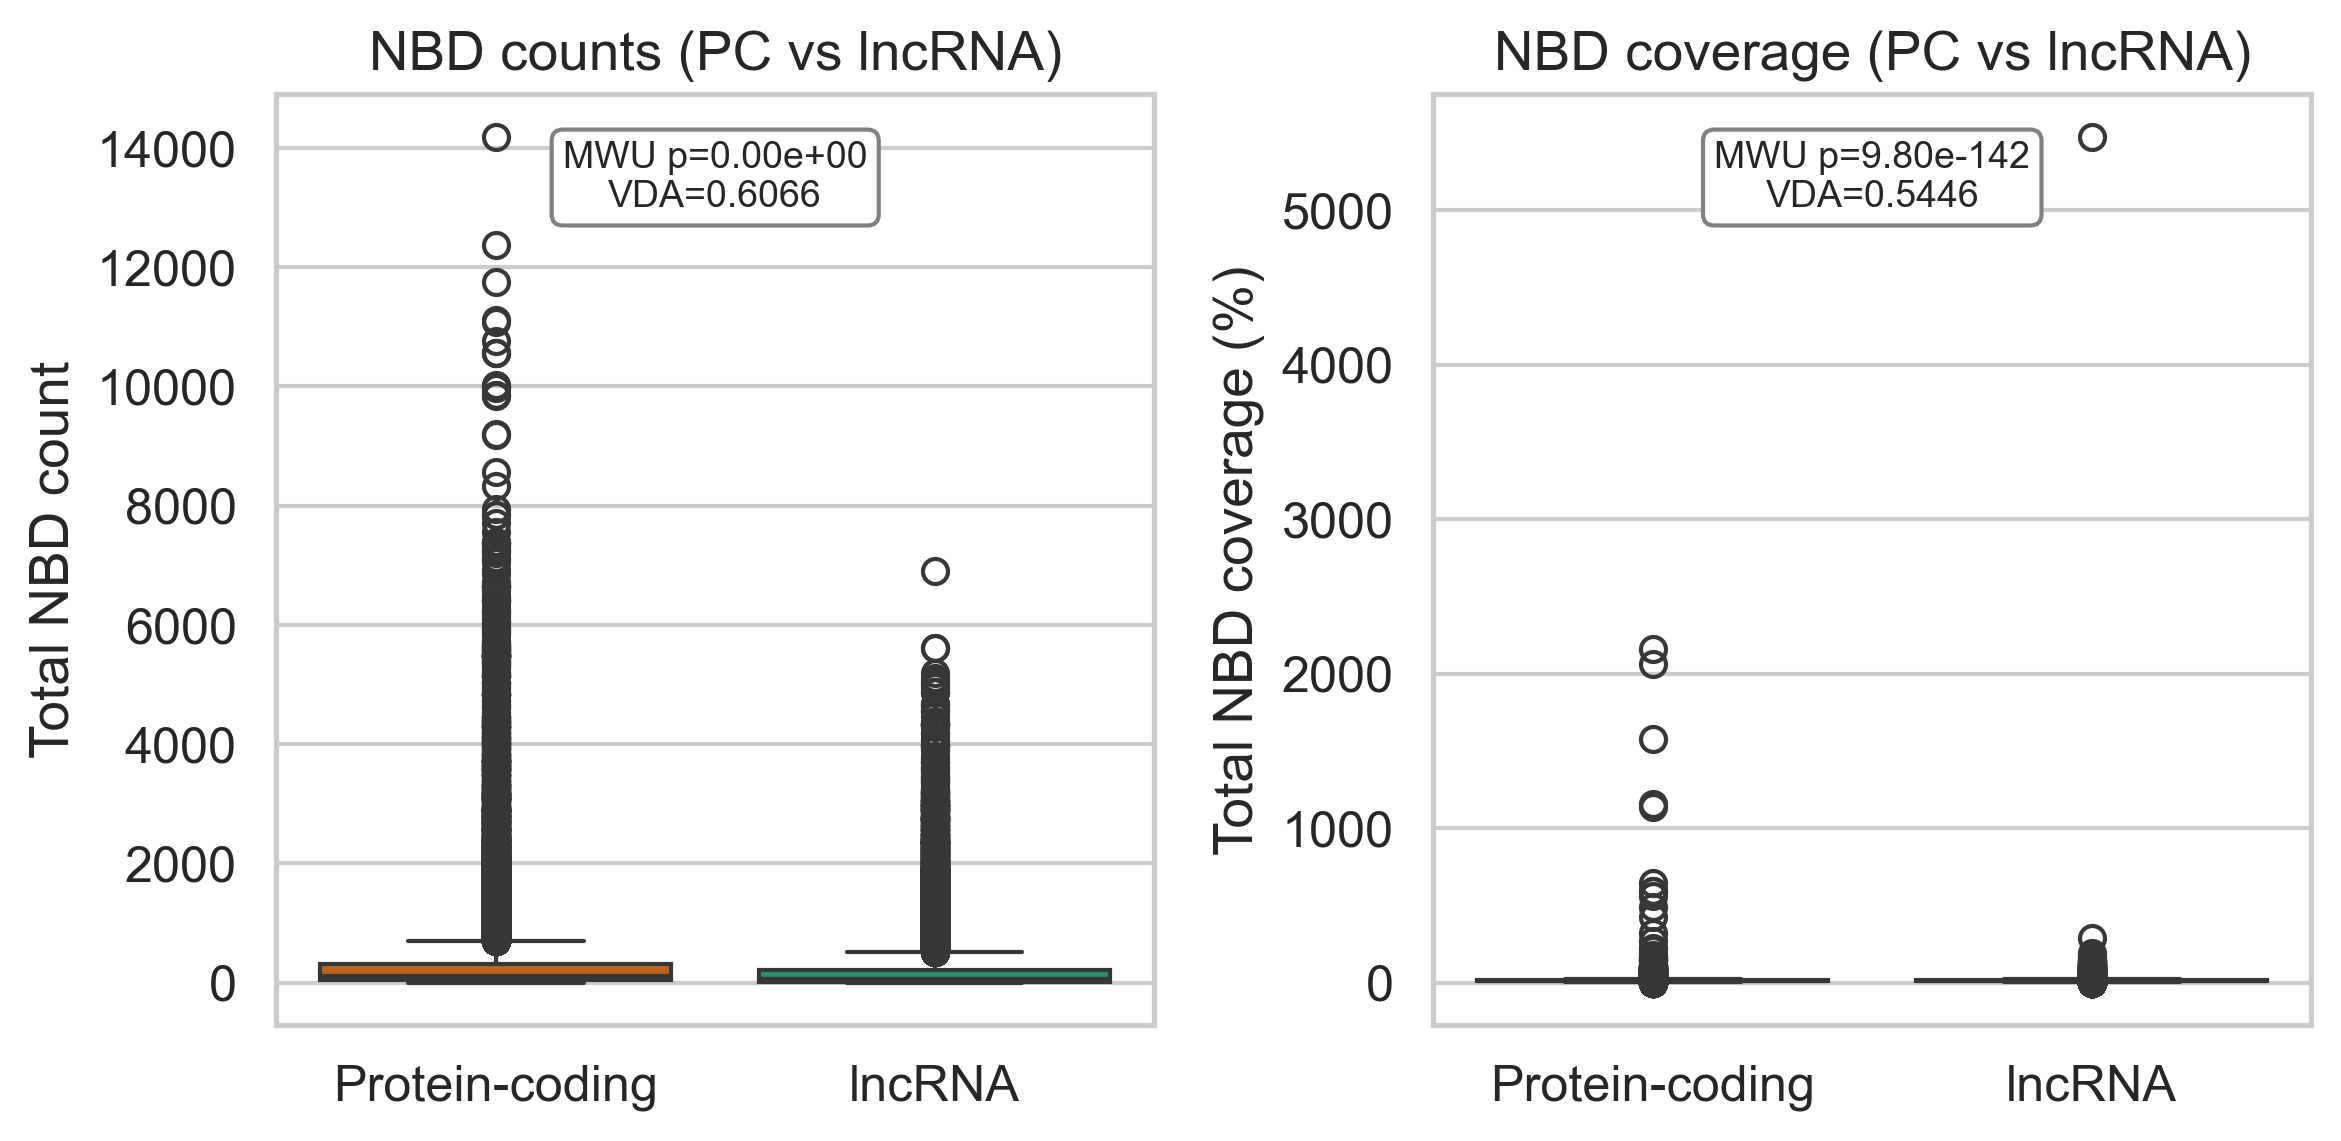

In [ ]:
# Plotting the total NBD counts and coverage for PC vs lncRNA, with MWU p-values and VDA effect sizes annotated.

_cc = "total_nonb_count" #"gq_hit_count"
_vc = "total_nonb_coverage_pct" #"gq_unique_length_pct"

pc_counts = pd.to_numeric(nbd_pc_s[_cc], errors="coerce").dropna()
lnc_counts = pd.to_numeric(nbd_lnc_s[_cc], errors="coerce").dropna()
pc_cov = pd.to_numeric(nbd_pc_s[_vc], errors="coerce").dropna()
lnc_cov = pd.to_numeric(nbd_lnc_s[_vc], errors="coerce").dropna()

# MWU + VDA for counts
u_cnt, p_cnt = mannwhitneyu(pc_counts, lnc_counts, alternative="two-sided")
vda_cnt = _vda(u_cnt, len(pc_counts), len(lnc_counts))

# MWU + VDA for coverage
u_cov, p_cov = mannwhitneyu(pc_cov, lnc_cov, alternative="two-sided")
vda_cov = _vda(u_cov, len(pc_cov), len(lnc_cov))

# Prepare long-form data for seaborn
df_counts = pd.DataFrame({
    "value": pd.concat([pc_counts, lnc_counts]),
    "coding_class": (["coding"] * len(pc_counts)) + (["lncRNA"] * len(lnc_counts)),
})
df_cov = pd.DataFrame({
    "value": pd.concat([pc_cov, lnc_cov]),
    "coding_class": (["coding"] * len(pc_cov)) + (["lncRNA"] * len(lnc_cov)),
})

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

# Counts plot
ax = axes[0]
sns.boxplot(x="coding_class", y="value", data=df_counts, palette=CLASS_PALETTE, order=CLASS_ORDER, ax=ax)
#sns.stripplot(x="coding_class", y="value", data=df_counts, color="k", size=1.5, alpha=0.4, order=CLASS_ORDER, ax=ax)
ax.set_xlabel("")
ax.set_xticklabels([CLASS_LABELS[c] for c in CLASS_ORDER])
ax.set_ylabel("Total NBD count")
ax.set_title("NBD counts (PC vs lncRNA)")
ax.text(0.5, 0.95, f"MWU p={p_cnt:.2e}\nVDA={vda_cnt}", ha="center", va="top", transform=ax.transAxes, fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="0.5"))

# Coverage plot
ax = axes[1]
sns.boxplot(x="coding_class", y="value", data=df_cov, palette=CLASS_PALETTE, order=CLASS_ORDER, ax=ax)
#sns.stripplot(x="coding_class", y="value", data=df_cov, color="k", size=1.5, alpha=0.4, order=CLASS_ORDER, ax=ax)
ax.set_xlabel("")
ax.set_xticklabels([CLASS_LABELS[c] for c in CLASS_ORDER])
ax.set_ylabel("Total NBD coverage (%)")
ax.set_title("NBD coverage (PC vs lncRNA)")
ax.text(0.5, 0.95, f"MWU p={p_cov:.2e}\nVDA={vda_cov}", ha="center", va="top", transform=ax.transAxes, fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="0.5"))

plt.tight_layout()
plt.show()

In [ ]:
# ── Export: Comprehensive stats tables ────────────────────────────────────────
rep_comp_df.to_csv(TABLE_OUT / "S11a_rep_comprehensive_stats.csv", index=False)
nbd_comp_df.to_csv(TABLE_OUT / "S11b_nbd_comprehensive_stats.csv", index=False)
print(f"✓ Exported S11a_rep_comprehensive_stats.csv ({rep_comp_df.shape})")
print(f"✓ Exported S11b_nbd_comprehensive_stats.csv ({nbd_comp_df.shape})")


✓ Exported S11a_rep_comprehensive_stats.csv ((23, 22))
✓ Exported S11b_nbd_comprehensive_stats.csv ((9, 22))


## 4. RepeatMasker (RM) Analysis

Raw RepeatMasker analysis and per-family breakdowns.

In [ ]:
# Parse raw RepeatMasker output for per-family / per-class breakdown
# Columns: SW_score perc_div perc_del perc_ins query q_start q_end (q_left) strand repeat class/family [rm_start rm_end (rm_left) id]
rm_col_names = [
    "sw_score", "perc_div", "perc_del", "perc_ins",
    "transcript_id", "q_start", "q_end", "q_left",
    "strand", "repeat_name", "class_family",
    "rm_start", "rm_end", "rm_left", "rm_id",
]

rm = pd.read_csv(
    RM_OUT, sep=r"\s+", skiprows=3, header=None,
    names=rm_col_names, on_bad_lines="skip",
).set_index("transcript_id")

# Subset to transcripts in dataset
rm = rm.loc[rm.index.intersection(dset_ids)].copy()

rm["q_left"] = rm["q_left"].astype(str).str.strip("()")
rm["rm_left"] = rm["rm_left"].astype(str).str.strip("()")

# Split class/family column
rm[["rm_class", "rm_family"]] = rm["class_family"].str.split("/", n=1, expand=True)
rm["rm_family"] = rm["rm_family"].fillna(rm["rm_class"])

# Attach coding_class from REP feature table (join on index)
rm = rm.join(rep[["coding_class"]], how="left")

print(f"RepeatMasker hits: {len(rm):,}")
print(f"  Unique classes : {rm['rm_class'].nunique()}")
print(f"  Unique families: {rm['rm_family'].nunique()}")

rm_preview = rm.reset_index().rename(columns={rm.index.name or "index": "transcript_id"})
rm_preview[["transcript_id", "repeat_name", "rm_class", "rm_family", "coding_class"]].head(3)


RepeatMasker hits: 202,153
  Unique classes : 16
  Unique families: 53


,transcript_id,repeat_name,rm_class,rm_family,coding_class
0,ENST00000417324.2,FLAM_C,SINE,Alu,lncRNA
1,ENST00000417324.2,MIRb,SINE,MIR,lncRNA
2,ENST00000417324.2,MLT1J2,LTR,ERVL-MaLR,lncRNA


In [ ]:
# ── Per-family average hit count (mean hits per transcript, top-N families) ──
# Only keep TE hits (exclude Simple_repeat, Low_complexity, Unknown, Satellite)
rm_te = rm[~rm["rm_class"].isin(["Simple_repeat", "Low_complexity", "Unknown",
                                   "Satellite", "rRNA", "snRNA", "scRNA", "tRNA",
                                   "srpRNA"])].copy()
rm_te = rm_te[rm_te["coding_class"].isin(CLASS_ORDER)].copy()

n_transcripts = rep.groupby("coding_class")["transcript_length"].count()

# Hits per family per class
fam_hits = (rm_te.groupby(["rm_class", "rm_family", "coding_class"])
            .size()
            .reset_index(name="total_hits"))
fam_hits["mean_per_tx"] = fam_hits.apply(
    lambda r: r["total_hits"] / n_transcripts[r["coding_class"]], axis=1
)

# Top-20 families by combined mean
top_fams = (fam_hits.groupby("rm_family")["mean_per_tx"]
            .sum().sort_values(ascending=False).head(20).index.tolist())
fam_plot = fam_hits[fam_hits["rm_family"].isin(top_fams)].copy()
fam_plot["class_label"] = fam_plot["coding_class"].map(CLASS_LABELS)

print(f"Top-20 TE families (by combined mean hits/transcript):")
pivot_fam = fam_plot.pivot_table(index="rm_family", columns="coding_class",
                                  values="mean_per_tx").fillna(0)
display(pivot_fam.sort_values("coding", ascending=False).round(4))


Top-20 TE families (by combined mean hits/transcript):


coding_class,coding,lncRNA
rm_family,,
Alu,0.2896,0.3763
MIR,0.1123,0.2283
L1,0.1098,0.3027
L2,0.0682,0.1545
hAT-Charlie,0.0589,0.1029
ERVL-MaLR,0.0430,0.2711
TcMar-Tigger,0.0290,0.0532
ERV1,0.0270,0.2055
ERVL,0.0224,0.1225


In [ ]:
# ── Export: Top-20 TE families ────────────────────────────────────────────────
fam_export = fam_plot.copy()
fam_export.to_csv(TABLE_OUT / "S3_te_top20_families.csv", index=False)
pivot_fam.to_csv(TABLE_OUT / "S3_te_top20_families_pivot.csv")
print(f"✓ Exported S3_te_top20_families.csv ({fam_export.shape})")
print(f"✓ Exported S3_te_top20_families_pivot.csv ({pivot_fam.shape})")

✓ Exported S3_te_top20_families.csv ((40, 6))
✓ Exported S3_te_top20_families_pivot.csv ((20, 2))
